## Pressupostos/Passos

* Verificar normalidade dos dados (univariada x multivariada)
* Verificar a homogeneidade das matrizes covariância-variância entre os grupos (teste M de box)
* Verificar se há outliers multivariados (pelo cálculo da distância de Mahalanobis)
* Verificar se há multicolinearidade
* verificar a linearidade entre os pares de observações
* Fazer, interpretar e descrever a MANOVA



# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.multivariate.manova import MANOVA
from scipy import stats

# Análise de dados

In [2]:
# importando os dados
df = pd.read_csv('/content/drive/MyDrive/Trabalhos/imoveis/imoveis_modelo.csv',
                 sep=';')

In [3]:
# Visualizando as primeiras linhas
df.head()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
0,875000.0,9408.0,3,2,2,93.0,-15.840670,-48.022060
1,650000.0,6842.0,3,2,2,95.0,-15.840670,-48.022060
2,740000.0,7312.0,1,2,2,101.0,-15.840670,-48.022060
3,1480000.0,8222.0,4,2,2,180.0,-15.835735,-48.028668
4,1180000.0,9007.0,3,3,3,131.0,-15.840610,-48.027707


In [4]:
# Informacoes sobre a base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3470 entries, 0 to 3469
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   preco      3470 non-null   float64
 1   valor_m2   3470 non-null   float64
 2   quartos    3470 non-null   int64  
 3   suites     3470 non-null   int64  
 4   vagas      3470 non-null   int64  
 5   espaco     3470 non-null   float64
 6   latitude   3470 non-null   float64
 7   longitude  3470 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 217.0 KB


In [5]:
# Descricao dos dados
df.describe()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
count,3.470000e+03,3.470000e+03,3470.000000,3470.000000,3470.000000,3470.000000,3470.000000,3470.000000
mean,8.839490e+05,5.388185e+04,2.412392,1.503746,1.503746,88.384438,-15.839318,-48.025622
std,8.404084e+06,2.514623e+06,1.030924,1.019195,1.019195,52.610030,0.005977,0.008562
min,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,0.000000,-15.877306,-48.047945
25%,4.250000e+05,7.571500e+03,2.000000,1.000000,1.000000,51.250000,-15.840670,-48.032815
50%,6.300000e+05,8.523500e+03,2.000000,2.000000,2.000000,75.000000,-15.839594,-48.022060
75%,8.900000e+05,9.408000e+03,3.000000,2.000000,2.000000,110.000000,-15.836665,-48.022060
max,4.950000e+08,1.480000e+08,5.000000,5.000000,5.000000,450.000000,-15.827535,-47.994065


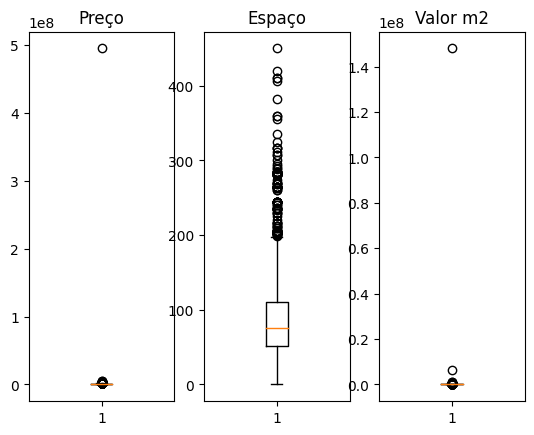

In [6]:
# Boxplot das variaveis continuas
fig, ax = plt.subplots(1, 3)

ax[0].boxplot(df['preco'])
ax[0].set_title('Preço')

ax[1].boxplot(df['espaco'])
ax[1].set_title('Espaço')

ax[2].boxplot(df['valor_m2'])
ax[2].set_title('Valor m2')

fig.show();

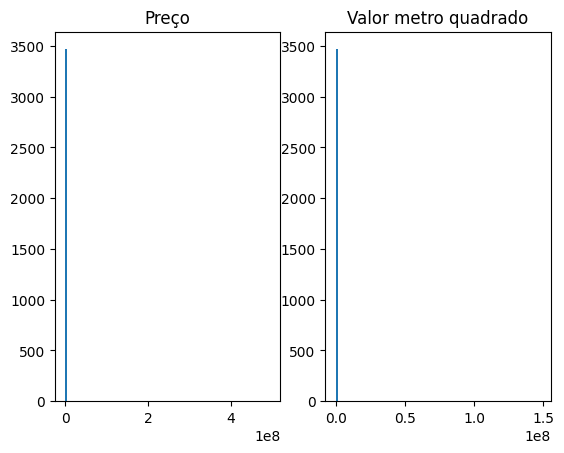

In [7]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(df.preco, bins=100)
ax[0].set_title('Preço')

ax[1].hist(df.valor_m2, bins=100)
ax[1].set_title('Valor metro quadrado')

fig.show();

In [8]:
index_50mil = df[df.preco < 50000].index
df.loc[index_50mil]

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
127,1145.0,9.0,3,2,2,122.0,-15.840670,-48.022060
271,1070.0,8.0,4,3,3,124.0,-15.836200,-48.033500
971,477.0,10.0,1,1,1,44.0,-15.836050,-48.019530
1012,1300.0,9.0,3,3,3,139.0,-15.840670,-48.022060
1084,0.0,0.0,1,1,1,57.0,-15.840670,-48.022060
1101,1.0,0.0,3,3,3,90.0,-15.840055,-48.022310
1329,0.0,0.0,4,3,3,203.0,-15.840670,-48.022060
1418,0.0,0.0,2,2,2,74.0,-15.840670,-48.022060
1434,1429.0,8.0,4,3,3,169.0,-15.840670,-48.022060
1709,1.0,0.0,2,1,1,54.0,-15.840670,-48.022060


In [9]:
# Excluindo os registros com preco abaixo de 50mil
df.drop(index=index_50mil, inplace=True)

In [10]:
# Excluindo os valores extremos de preco e valor do metro quadrado
df.drop(index=df[df.preco == df.preco.max()].index, inplace=True)
df.drop(index=df[df.valor_m2 == df.valor_m2.max()].index, inplace=True)

In [11]:
# Descricao dos dados
df.describe()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
count,3.455000e+03,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000
mean,7.440855e+05,9488.415051,2.410130,1.499566,1.499566,88.292041,-15.839317,-48.025628
std,4.757978e+05,30008.748353,1.030491,1.017472,1.017472,52.503322,0.005989,0.008574
min,7.500000e+04,1730.000000,1.000000,0.000000,0.000000,0.000000,-15.877306,-48.047945
25%,4.300000e+05,7586.000000,2.000000,1.000000,1.000000,51.000000,-15.840670,-48.032815
50%,6.300000e+05,8533.000000,2.000000,2.000000,2.000000,75.000000,-15.839594,-48.022060
75%,8.900000e+05,9409.500000,3.000000,2.000000,2.000000,110.000000,-15.836665,-48.022060
max,5.496580e+06,970149.000000,5.000000,5.000000,5.000000,450.000000,-15.827535,-47.994065


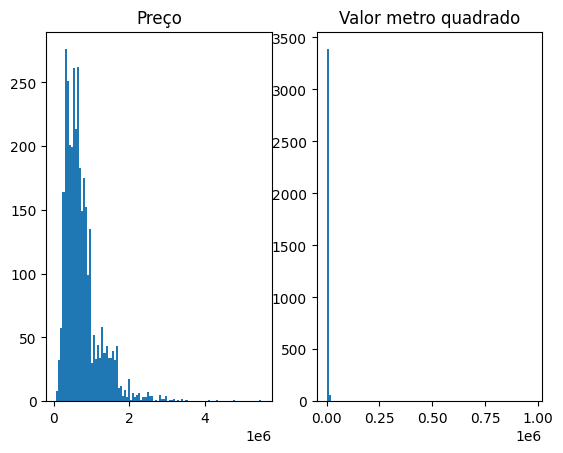

In [12]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(df.preco, bins=100)
ax[0].set_title('Preço')

ax[1].hist(df.valor_m2, bins=100)
ax[1].set_title('Valor metro quadrado')

fig.show();

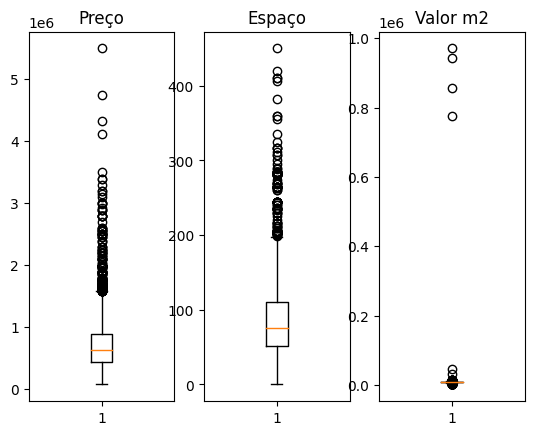

In [13]:
# Novo boxplot apos a retirada dos valores extremos
fig, ax = plt.subplots(1, 3)

ax[0].boxplot(df['preco'])
ax[0].set_title('Preço')

ax[1].boxplot(df['espaco'])
ax[1].set_title('Espaço')

ax[2].boxplot(df['valor_m2'])
ax[2].set_title('Valor m2')

fig.show();

In [14]:
# Excluindo pontos ainda muito discrepantes de metros quadrados
index_m2 = df.valor_m2.sort_values(ascending=False)[:4].index
df.drop(index=index_m2, inplace=True)

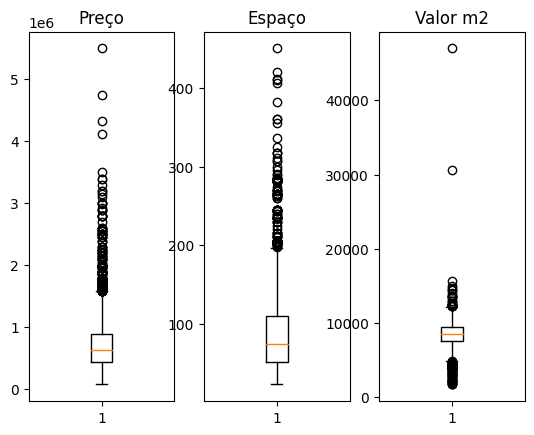

In [15]:
# Novo boxplot apos a retirada dos valores extremos
fig, ax = plt.subplots(1, 3)
# Boxplot de precos
ax[0].boxplot(df['preco'])
ax[0].set_title('Preço')
# Boxplot de espaco
ax[1].boxplot(df['espaco'])
ax[1].set_title('Espaço')
# Boxplot do valor do metro quadrado
ax[2].boxplot(df['valor_m2'])
ax[2].set_title('Valor m2')

fig.show();

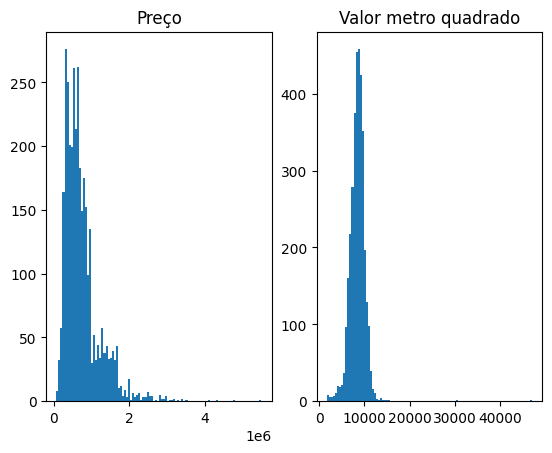

In [16]:
# Plot
fig, ax = plt.subplots(1, 2)
# Plot histograma precos
ax[0].hist(df.preco, bins=100)
ax[0].set_title('Preço')
# Plot histograma metro quadrado
ax[1].hist(df.valor_m2, bins=100)
ax[1].set_title('Valor metro quadrado')
# Mostrar a figura
fig.show();

In [17]:
df.describe()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
count,3.451000e+03,3451.000000,3451.000000,3451.000000,3451.000000,3451.000000,3451.000000,3451.000000
mean,7.437164e+05,8472.433498,2.409447,1.498696,1.498696,88.393509,-15.839318,-48.025624
std,4.757367e+05,1698.621592,1.030049,1.016494,1.016494,52.449014,0.005992,0.008574
min,7.500000e+04,1730.000000,1.000000,0.000000,0.000000,23.000000,-15.877306,-48.047945
25%,4.300000e+05,7586.000000,2.000000,1.000000,1.000000,52.000000,-15.840670,-48.032815
50%,6.300000e+05,8527.000000,2.000000,2.000000,2.000000,75.000000,-15.839594,-48.022060
75%,8.900000e+05,9408.000000,3.000000,2.000000,2.000000,110.000000,-15.836665,-48.022060
max,5.496580e+06,46969.000000,5.000000,5.000000,5.000000,450.000000,-15.827535,-47.994065


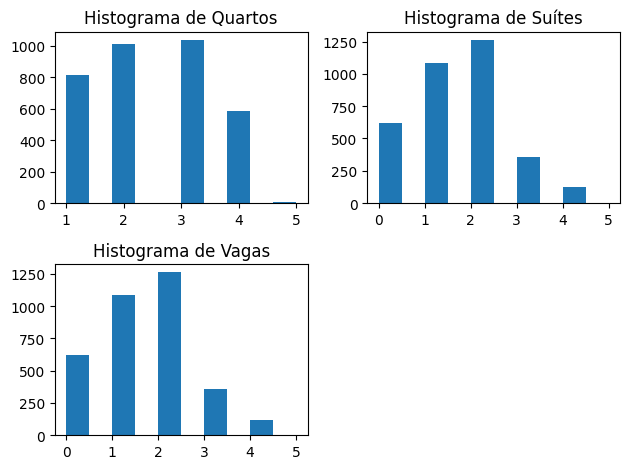

In [18]:
# Plot
fig, ax = plt.subplots(2, 2)
# Plot do histograma de quartos
ax[0, 0].hist(df['quartos'])
ax[0, 0].set_title('Histograma de Quartos')

# Plot do histograma de suítes
ax[0, 1].hist(df['suites'])
ax[0, 1].set_title('Histograma de Suítes')

# Plot do histograma de vagas
ax[1, 0].hist(df['vagas'])
ax[1, 0].set_title('Histograma de Vagas')

# Esconder o último subplot vazio
ax[1, 1].axis('off')

# Ajustar os espaçamentos entre os subplots
plt.tight_layout()

# Mostrar a figura
plt.show()

Podemos ver que quantidade de vagas e suites apresentam exatamente a mesma distribuição.

In [19]:
df.corr()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
preco,1.000000,0.227211,0.710045,0.761893,0.761893,0.929146,0.086921,0.101434
valor_m2,0.227211,1.000000,-0.077541,0.021443,0.021443,-0.062381,0.169384,-0.094049
quartos,0.710045,-0.077541,1.000000,0.799590,0.799590,0.753182,0.054752,0.103446
suites,0.761893,0.021443,0.799590,1.000000,1.000000,0.770652,0.070135,0.113442
vagas,0.761893,0.021443,0.799590,1.000000,1.000000,0.770652,0.070135,0.113442
espaco,0.929146,-0.062381,0.753182,0.770652,0.770652,1.000000,0.045211,0.133695
latitude,0.086921,0.169384,0.054752,0.070135,0.070135,0.045211,1.000000,0.022657
longitude,0.101434,-0.094049,0.103446,0.113442,0.113442,0.133695,0.022657,1.000000


<Axes: title={'center': 'Correlação entre variáveis'}>

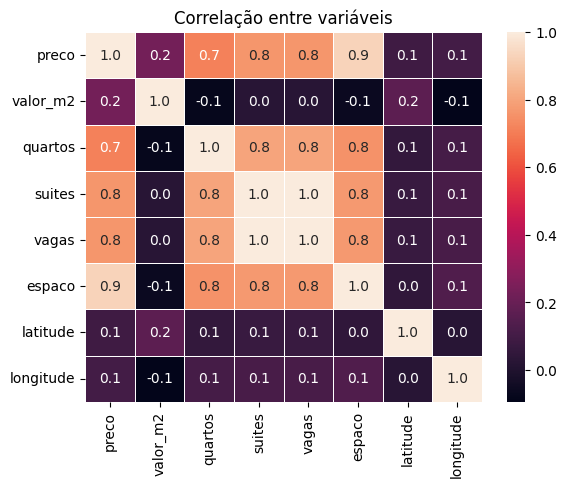

In [20]:
import seaborn as sns
plot = sns.heatmap(df.corr(), annot = True, fmt=".1f", linewidths=.6)
plot.set_title('Correlação entre variáveis')
plot

In [21]:
df2 = pd.DataFrame(columns=['preco', 'm2'])
df2['preco'], df2['m2'] = df.preco, df.valor_m2 * df.espaco

In [22]:
df2.describe()

,preco,m2
count,3.451000e+03,3.451000e+03
mean,7.437164e+05,7.433522e+05
std,4.757367e+05,4.757195e+05
min,7.500000e+04,7.497000e+04
25%,4.300000e+05,4.294695e+05
50%,6.300000e+05,6.299370e+05
75%,8.900000e+05,8.898890e+05
max,5.496580e+06,5.496428e+06


In [23]:
df2.corr()

,preco,m2
preco,1.000000,0.999996
m2,0.999996,1.000000


<Axes: xlabel='m2'>

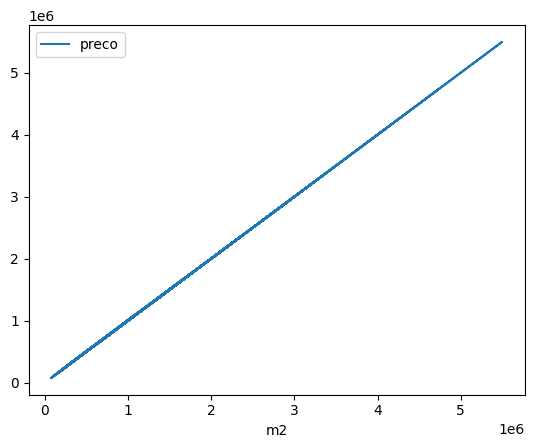

In [24]:
df2.plot(y='preco', x='m2')

In [25]:
# df.to_csv('/content/drive/MyDrive/Trabalhos/imoveis/imoveis_modelo2.csv',
#           sep=';',
#           encoding='utf-8',
#           index=False)

# PCA

In [26]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [27]:
df.reset_index(inplace=True)
df.drop(columns='index', inplace=True)

In [28]:
X = df[['quartos', 'suites', 'vagas', 'espaco', 'latitude', 'longitude']]
y = df[['preco']]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
X_train['espaco'] = (X_train.espaco - X_train.espaco.mean()) / X_train.espaco.std()
X_train['latitude'] = (X_train.latitude - X_train.latitude.mean()) / X_train.latitude.std()
X_train['longitude'] = (X_train.longitude - X_train.longitude.mean()) / X_train.longitude.std()

y_train = (y_train - y_train.mean()) / y_train.std()

In [31]:
X_test = (X_test - X_train.espaco.mean()) / X_train.espaco.std()
y_test = (y_test - y_train.mean()) / y_train.std()

In [32]:
# Selecionar as variáveis relevantes
variables_std = X_train[['quartos',
                        'suites',
                        'vagas',
                        'espaco',
                        'latitude',
                        'longitude']]

In [33]:
# Realizar a análise de PCA
pca = PCA()
pca.fit(variables_std)# Obter as proporções da variância explicada
explained_variance_ratio = pca.explained_variance_ratio_

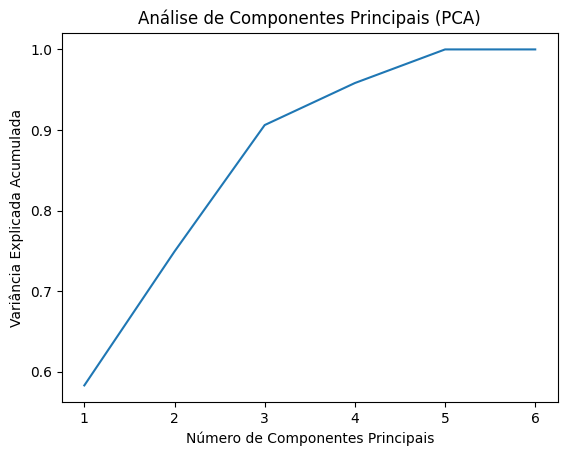

                PC1       PC2       PC3       PC4       PC5           PC6
quartos    0.490518  0.067224 -0.024692  0.353164 -0.793434 -7.269940e-16
suites     0.516060  0.042395 -0.030363 -0.466380  0.115986 -7.071068e-01
vagas      0.516060  0.042395 -0.030363 -0.466380  0.115986  7.071068e-01
espaco     0.465234  0.037192  0.014205  0.662822  0.585354 -5.551115e-17
latitude   0.050954 -0.780251 -0.622873  0.024986 -0.004101  7.632783e-17
longitude  0.087852 -0.617828  0.780624 -0.017234 -0.029998 -1.040834e-17


In [34]:
# Plotar a variância explicada acumulada
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio)
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Análise de Componentes Principais (PCA)')
plt.show();

# Obter os coeficientes do PCA (cargas)
loadings = pca.components_

# Mostrar os coeficientes e suas respectivas variáveis
loadings_df = pd.DataFrame(loadings.T, columns=['PC{}'.format(i+1) for i in range(len(loadings))], index=variables_std.columns)
print(loadings_df)

# Regressão linear

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn import ensemble
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import cross_val_score, KFold

In [36]:
X_train = X_train[['suites', 'espaco','latitude', 'longitude']]
X_test = X_test[['suites', 'espaco', 'latitude', 'longitude']]

In [37]:
# reg = LinearRegression()
# model = reg.fit(X_train, y_train)
reg = ensemble.GradientBoostingRegressor()
model = reg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [38]:
model.score(X_train, y_train)

0.9450182030669649

In [39]:
model.score(X_test.values, y_test.values)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


-2.5862169890434235

In [40]:
kfold = KFold(n_splits=15, shuffle=True, random_state=5)

In [41]:
resultado = cross_val_score(model, X_test, y_test, cv=kfold)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
 

In [42]:
print('Acurácia Média: %.2f%%' % (resultado.mean() * 100.0))

Acurácia Média: 87.81%


# titulo

## subtitulo

# Regressão linear bayesiana

In [ ]:
!pip install bambi -q

In [ ]:
import bambi as bmb
import pymc as pm
import seaborn as sns
import arviz as az
from bambi.plots import plot_cap

In [ ]:
df = pd.get_dummies(df[['preco', 'suites', 'latitude', 'longitude']], columns=['suites'], drop_first=True)

In [ ]:
# Create a Bayesian linear regression model with a gamma prior
model = bmb.Model('preco ~ suites_1 + suites_2 + suites_3 + suites_4 + suites_5 + latitude + longitude',
                  family='gamma',
                  data=df)

# Fit the model
result = model.fit()

In [ ]:
# Create a Bayesian linear regression model with a gamma prior
model = bmb.Model('preco ~ suites_1 + suites_2 + suites_3 + suites_4 + suites_5 + latitude + longitude',
                #   family='gamma',
                  data=df)

# Fit the model
result = model.fit()

In [ ]:
# Key summary and diagnostic info on the model parameters
az.summary(result)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,11.376,31.824,-20.440,43.193,22.413,18.960,2.0,13.0,2.46
suites_1,-0.772,0.075,-0.846,-0.697,0.053,0.044,2.0,11.0,3.04
suites_2,-0.029,0.474,-0.502,0.445,0.334,0.282,2.0,11.0,3.04
suites_3,-0.627,0.130,-0.757,-0.497,0.092,0.078,2.0,11.0,3.04
suites_4,-0.327,0.128,-0.455,-0.199,0.090,0.076,2.0,11.0,3.04
suites_5,0.251,0.535,-0.284,0.785,0.376,0.318,2.0,21.0,2.54
latitude,0.547,0.001,0.546,0.548,0.001,0.001,2.0,13.0,2.89
longitude,0.040,0.662,-0.622,0.701,0.466,0.394,3.0,19.0,2.24
preco_alpha,0.812,0.023,0.788,0.835,0.017,0.014,2.0,11.0,3.04


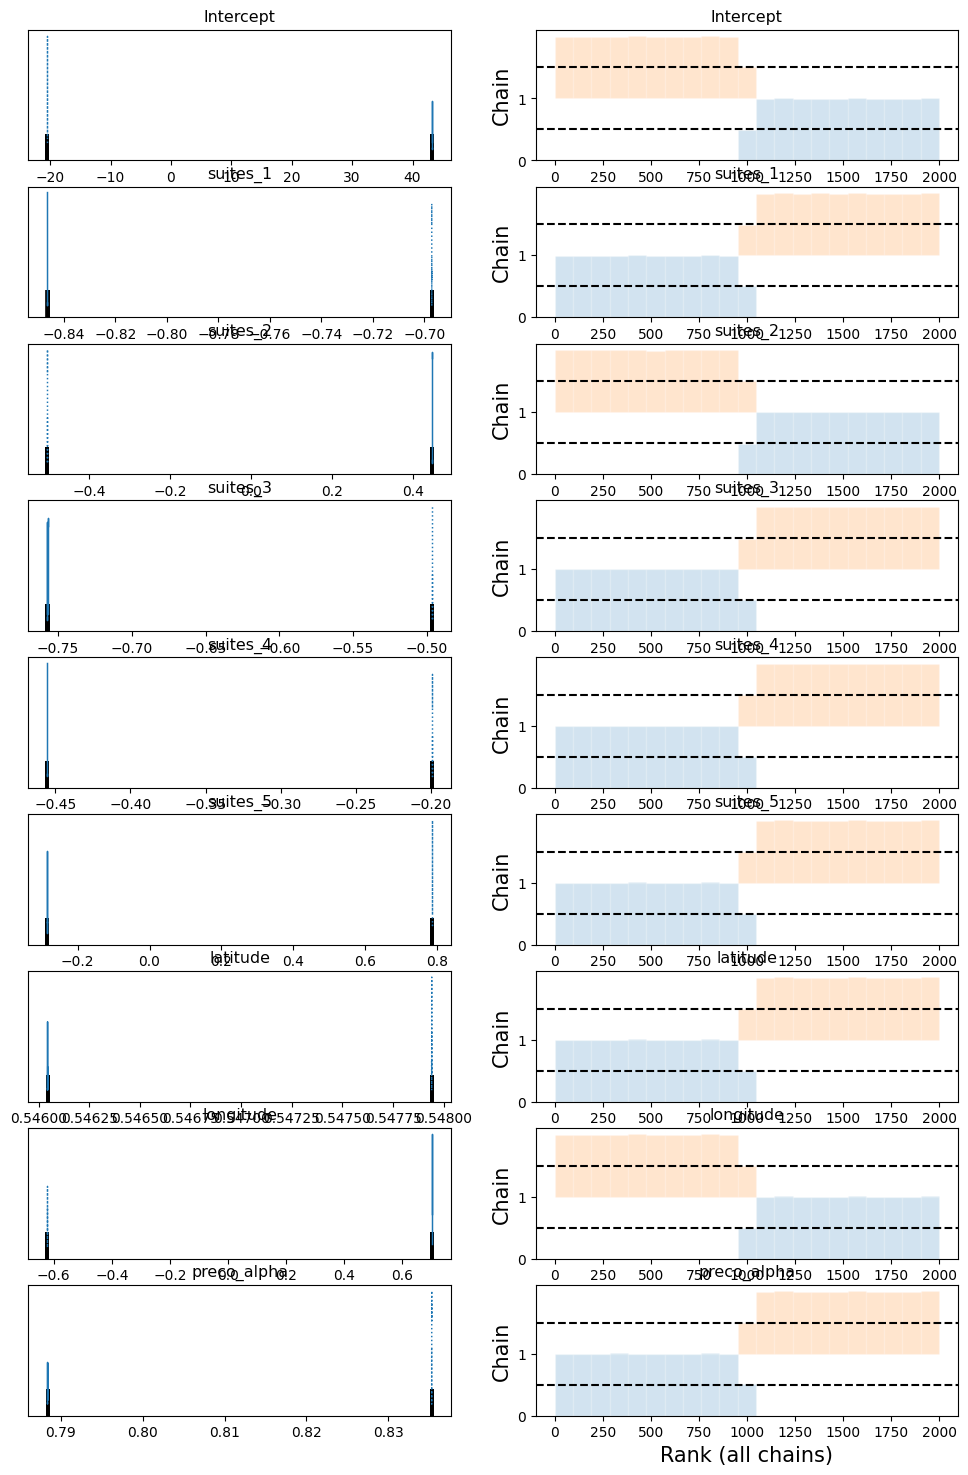

In [ ]:
# Use ArviZ to plot the results
# az.plot_trace(result)
az.plot_trace(result, kind="rank_bars");

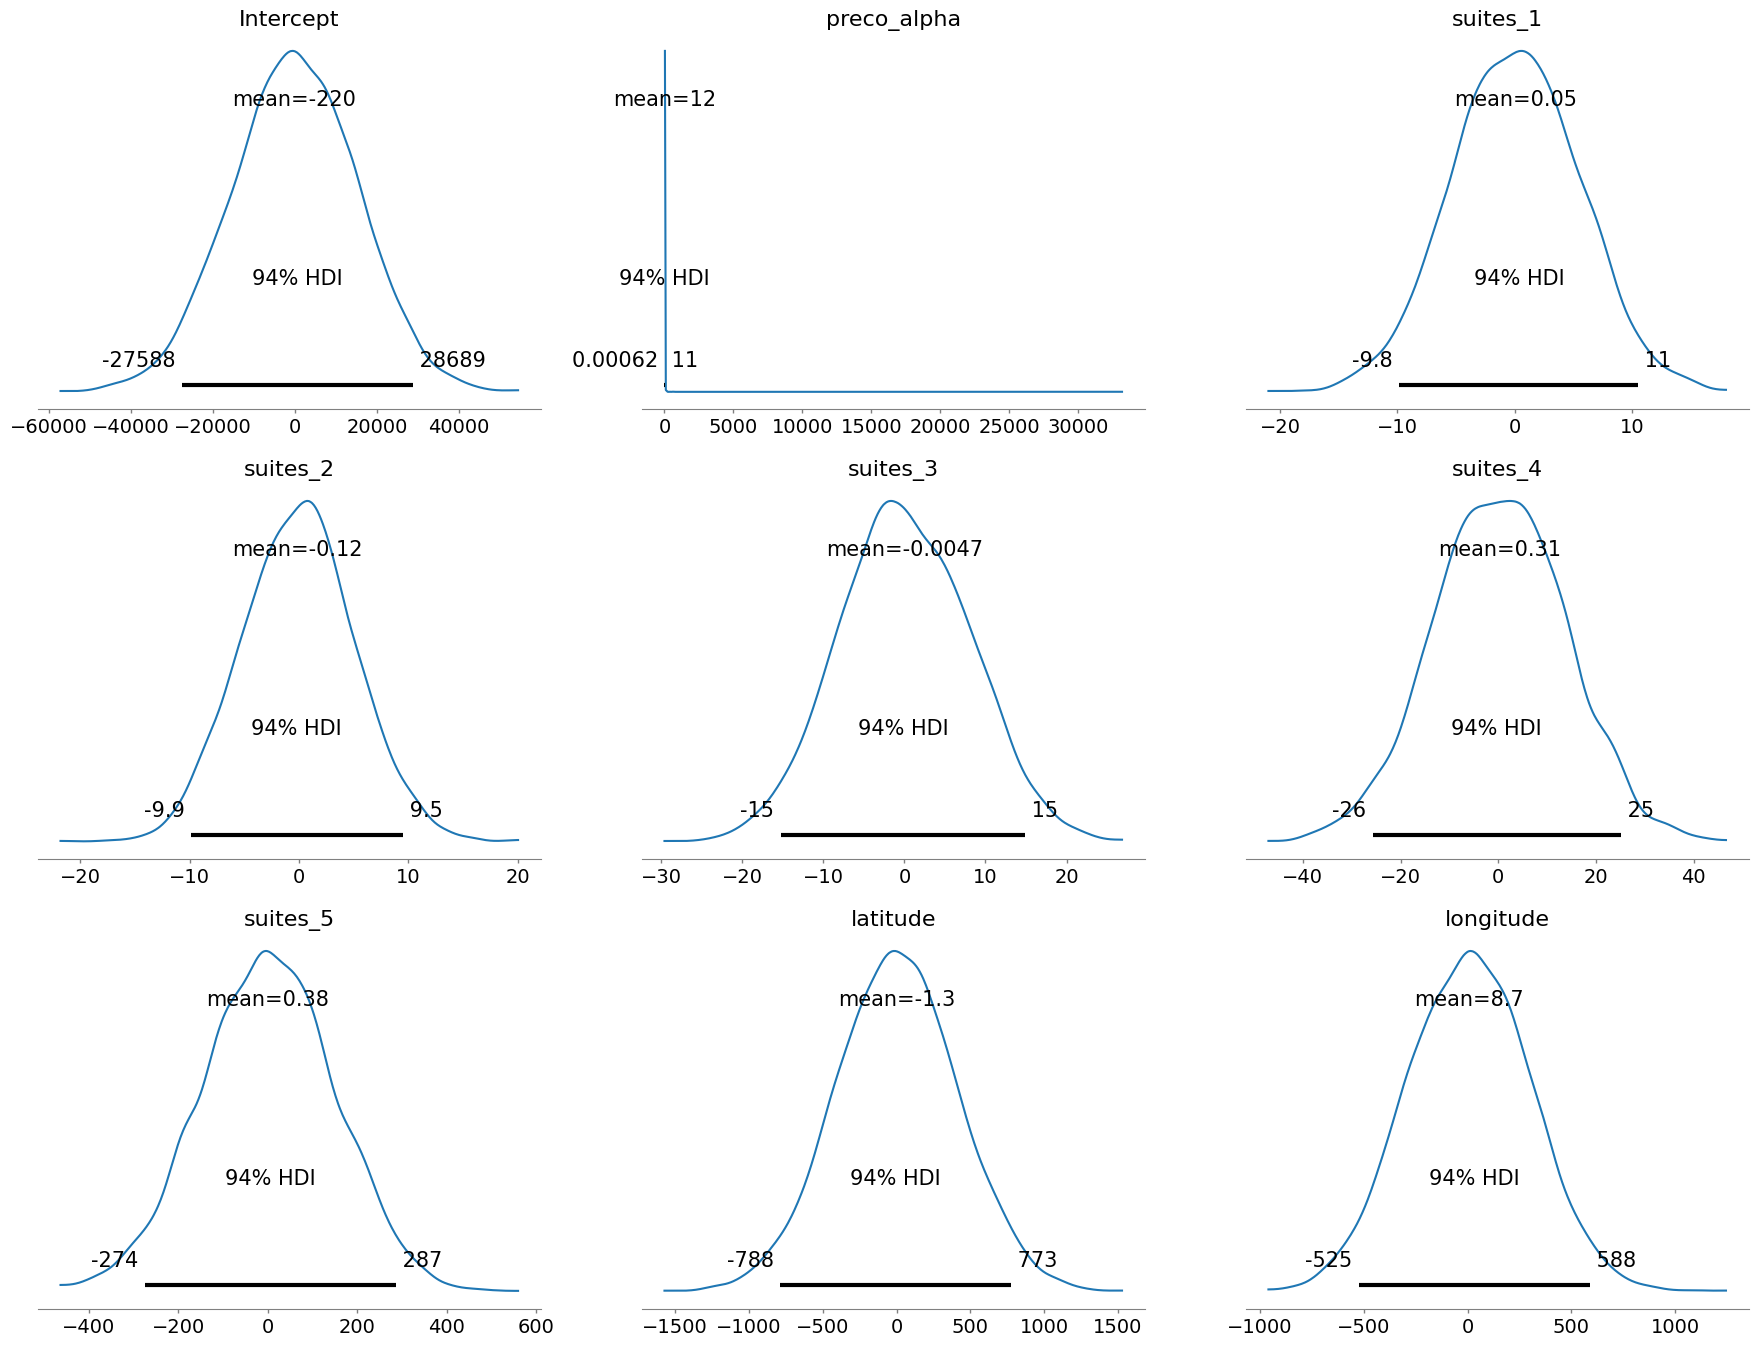

In [ ]:
model.plot_priors();

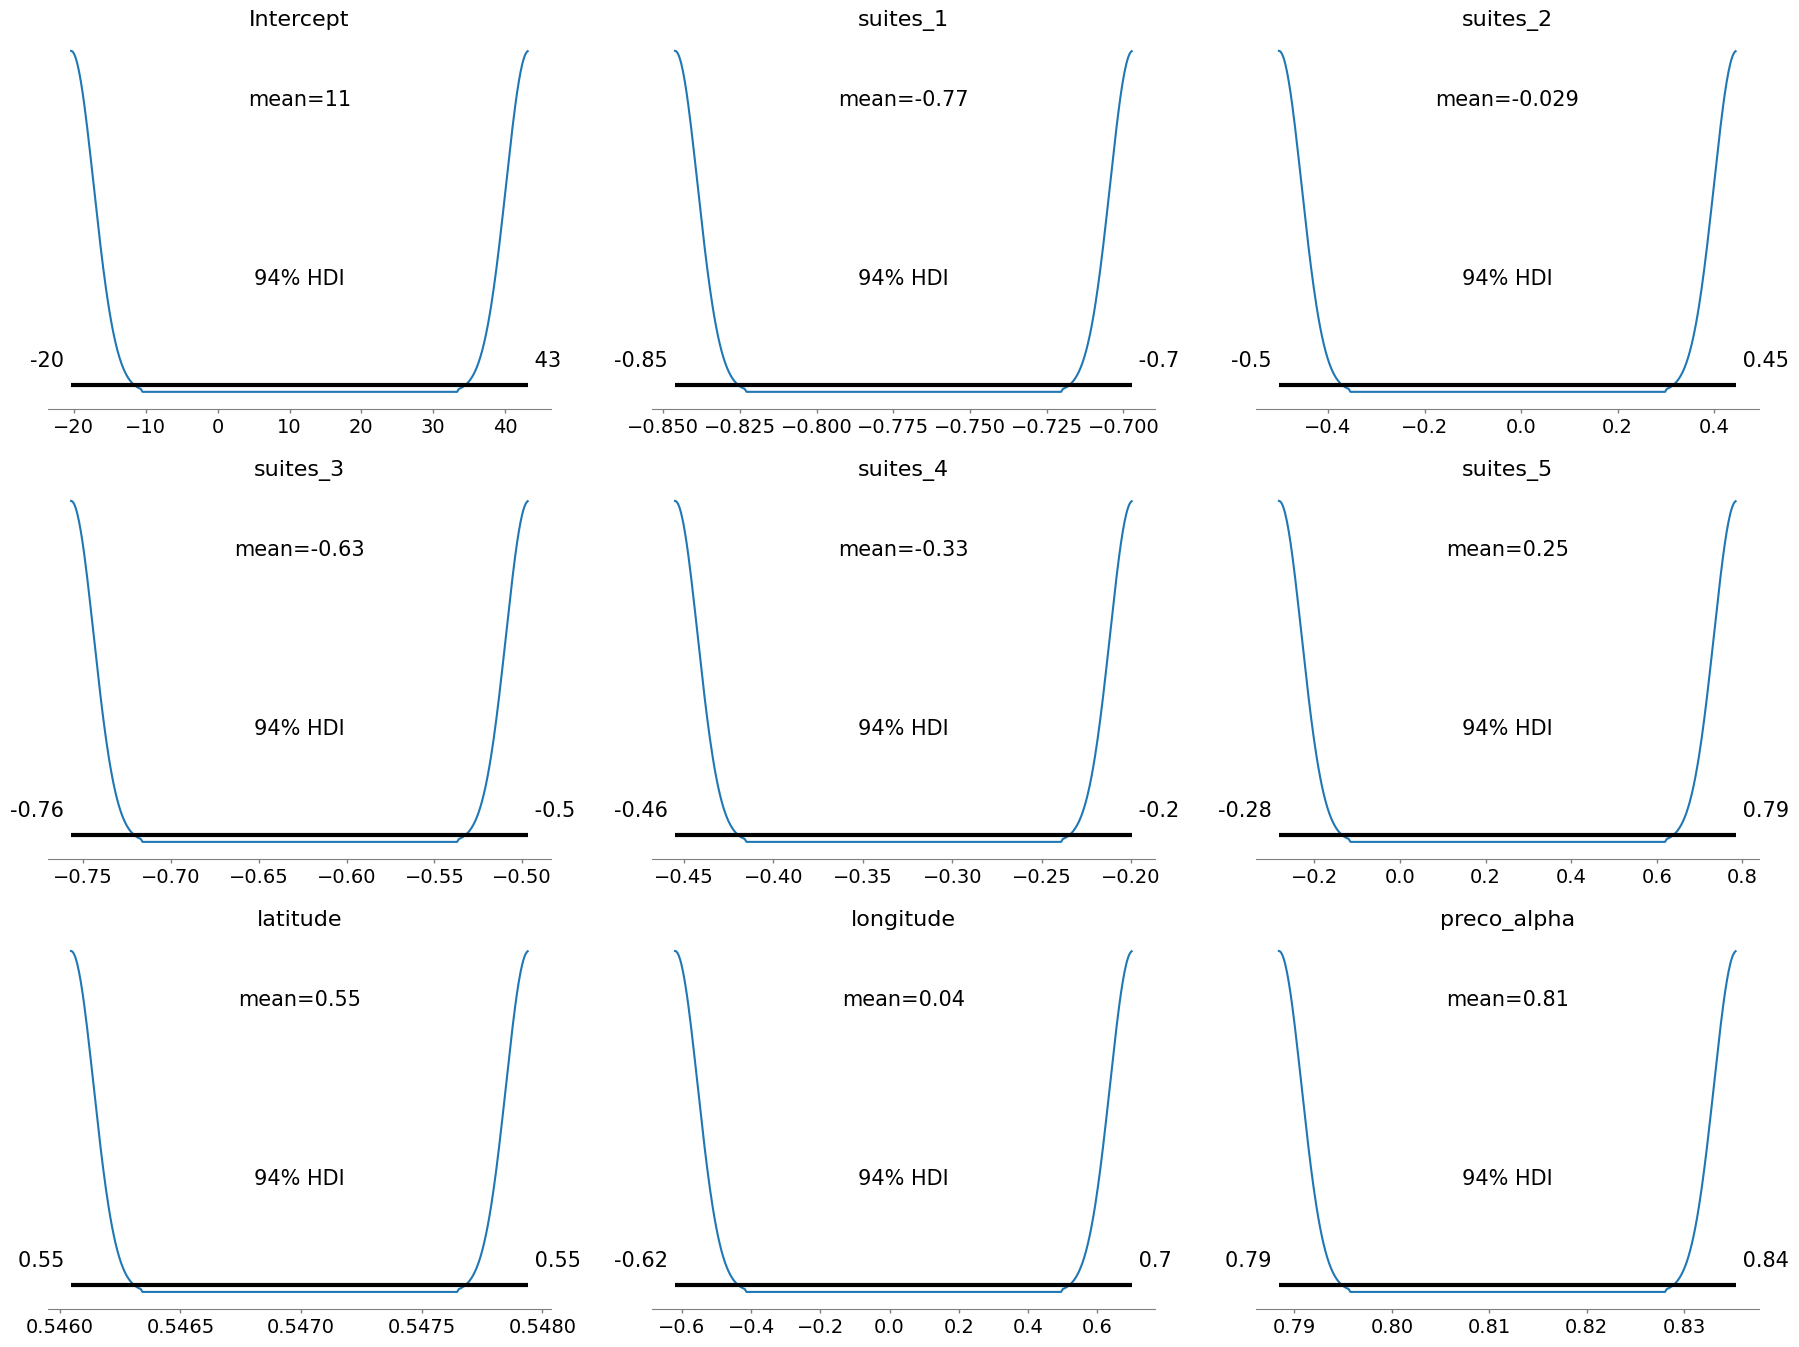

In [ ]:
az.plot_posterior(result);

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'suites_1'}>,
        <Axes: title={'center': 'suites_1'}>],
       [<Axes: title={'center': 'suites_2'}>,
        <Axes: title={'center': 'suites_2'}>],
       [<Axes: title={'center': 'suites_3'}>,
        <Axes: title={'center': 'suites_3'}>],
       [<Axes: title={'center': 'suites_4'}>,
        <Axes: title={'center': 'suites_4'}>],
       [<Axes: title={'center': 'suites_5'}>,
        <Axes: title={'center': 'suites_5'}>],
       [<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'longitude'}>],
       [<Axes: title={'center': 'preco_alpha'}>,
        <Axes: title={'center': 'preco_alpha'}>]], dtype=object)

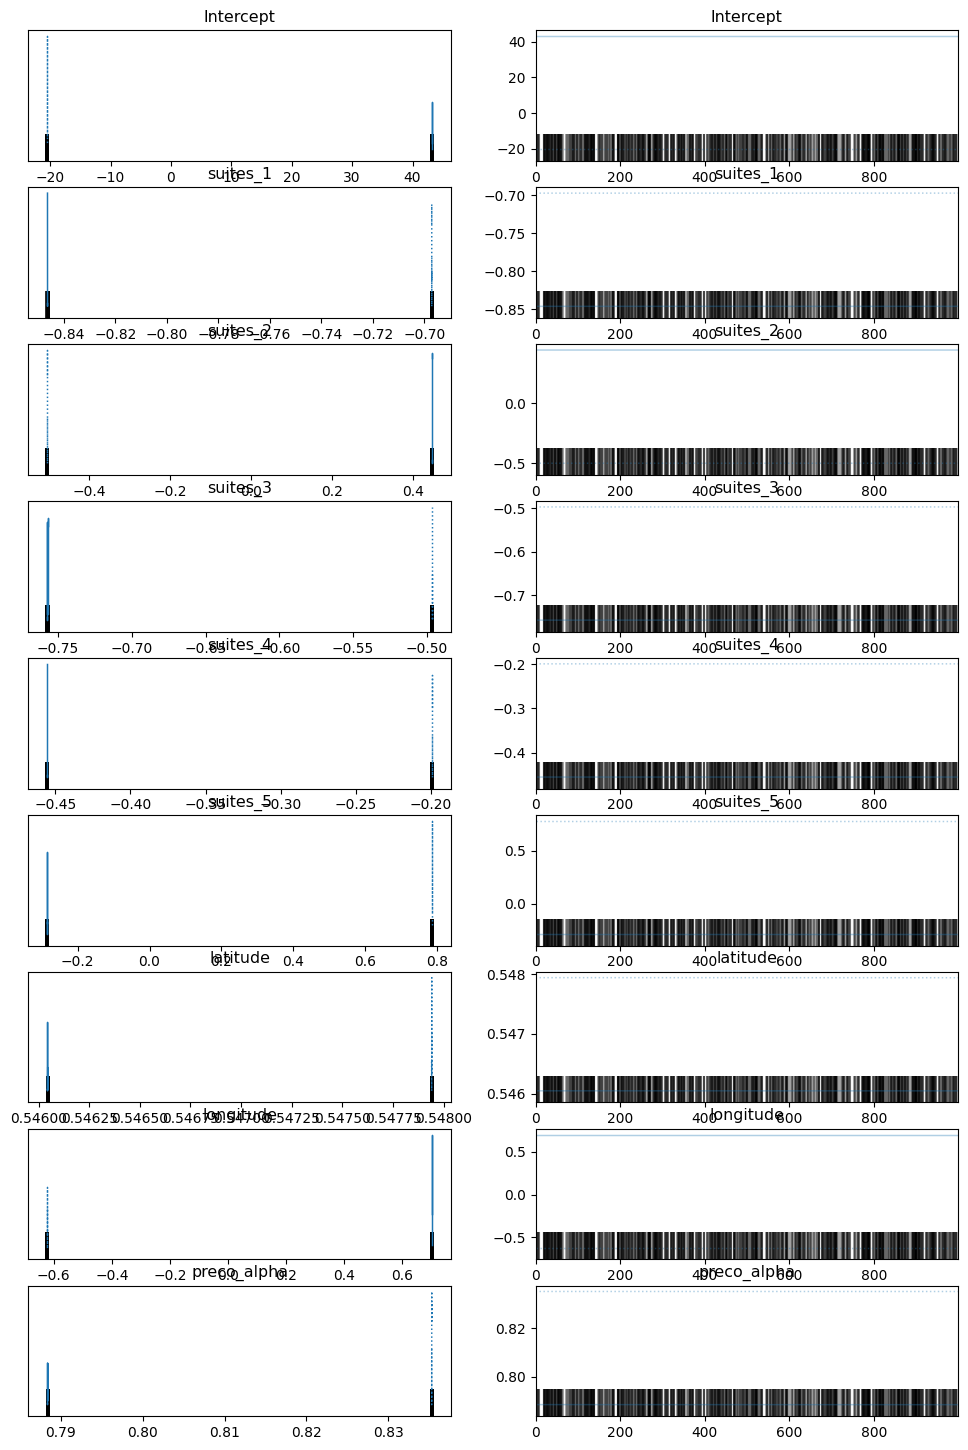

In [ ]:
az.plot_trace(result)

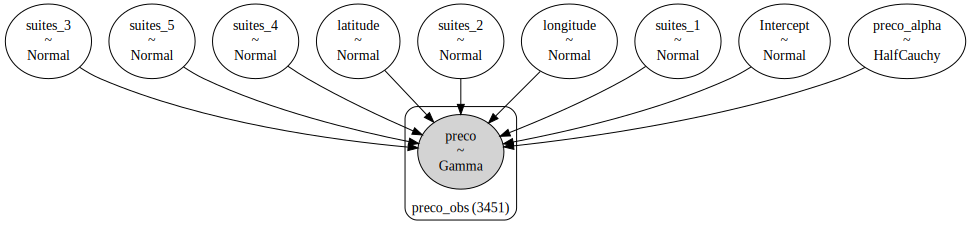

In [ ]:
model.graph()

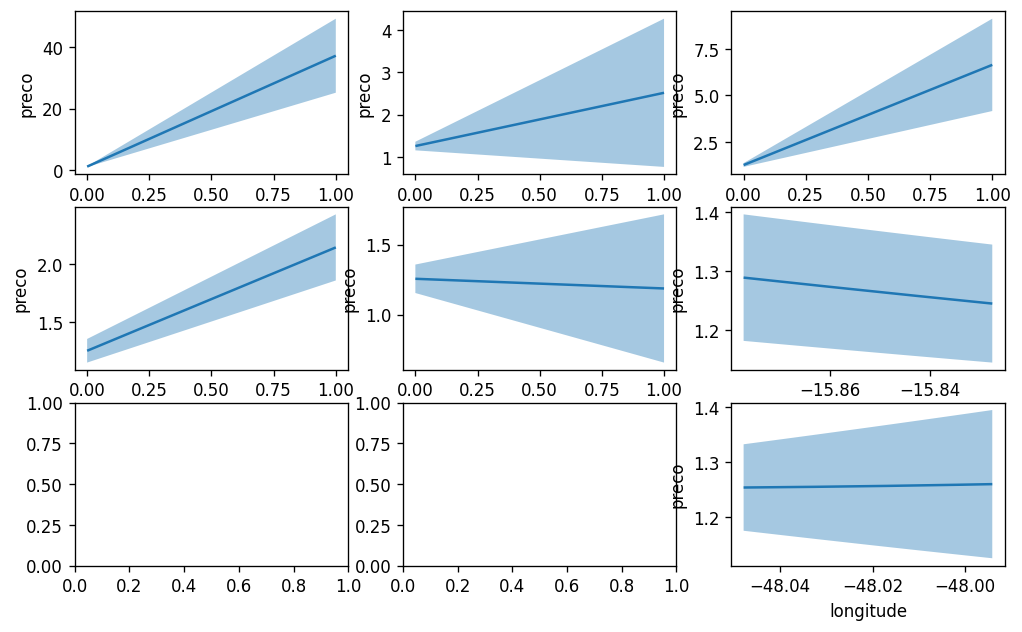

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(10, 6), dpi=120)
plot_cap(model, result, "suites_1", ax=ax[0,0])
plot_cap(model, result, "suites_2", ax=ax[0,1])
plot_cap(model, result, "suites_3", ax=ax[0,2])
plot_cap(model, result, "suites_4", ax=ax[1,0])
plot_cap(model, result, "suites_5", ax=ax[1,1])
plot_cap(model, result, "latitude", ax=ax[1,2])
plot_cap(model, result, "longitude", ax=ax[2,2]);

# Teste SEM

In [ ]:
!pip install semopy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [ ]:
import semopy
import numpy as np

# Carregar os dados
# df = pd.read_csv('seu_arquivo.csv')  # Substitua 'seu_arquivo.csv' pelo nome do seu arquivo de dados

# Selecionar as variáveis relevantes
variables = df[['valor_m2', 'latitude', 'longitude']]


# Definir as variáveis latentes e observadas
model_spec = '''
    latent_var =~ valor_m2 + latitude + longitude
'''


# Criar um modelo SEM (Structural Equation Model)
model = semopy.Model(model_spec)

# Ajustar o modelo aos dados
model.fit(df)

# Visualizar os resultados
print(model.inspect())

         lval  op        rval      Estimate       Std. Err    z-value  \
0    valor_m2   ~  latent_var  1.000000e+00              -          -   
1    latitude   ~  latent_var -6.573607e-05       3.651959  -0.000018   
2   longitude   ~  latent_var  2.864271e-01  362318.201976   0.000001   
3  latent_var  ~~  latent_var  9.347454e-04    1182.413351   0.000001   
4    latitude  ~~    latitude  4.301572e+01       1.035547  41.539138   
5   longitude  ~~   longitude  9.075902e-13      97.005807        0.0   
6    valor_m2  ~~    valor_m2  1.442240e+06   34740.145942  41.515071   

    p-value  
0         -  
1  0.999986  
2  0.999999  
3  0.999999  
4       0.0  
5       1.0  
6       0.0  


In [ ]:
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols
# from statsmodels.regression.structural_breaks import BreakpointOLS
from statsmodels.graphics.regressionplots import plot_fit, plot_regress_exog

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
scaled_data

array([[ 0.27599845,  0.55085964,  0.57340878, ..., -0.22565575,
         0.41570067,  0.61175358],
       [-0.19702081, -0.95999591,  0.57340878, ..., -0.22565575,
         0.41570067, -1.6499745 ],
       [-0.00781311, -0.68326087, -1.36852812, ..., -0.22565575,
         0.41570067, -1.6499745 ],
       ...,
       [-0.36520544,  1.11316169, -0.39755967, ..., -0.22565575,
         0.41570067, -1.00376648],
       [ 3.0405333 ,  0.47490471,  1.54437723, ..., -0.22565575,
         0.41570067,  0.61175358],
       [-0.9958978 , -2.81117667,  0.57340878, ..., -4.97906132,
        -0.16073223, -0.35755845]])

In [ ]:
modelo = 'var1 ~ x1 + x2'

In [ ]:
result = ols(modelo, data=scaled_data).fit()

In [ ]:
print(result.summary())

In [ ]:
plot_fit(result, exog_idx=1)

In [ ]:
plot_regress_exog(result, exog_idx=1)

# MANOVA

In [ ]:
fit = MANOVA.from_formula('valor_m2 + quartos + vagas + espaco + latitude + longitude ~ preco', data=df)
print(fit.mv_test())

                          Multivariate linear model
                                                                             
-----------------------------------------------------------------------------
       Intercept            Value     Num DF   Den DF      F Value     Pr > F
-----------------------------------------------------------------------------
          Wilks' lambda        0.0000 6.0000 3444.0000 6421822458.0206 0.0000
         Pillai's trace        1.0000 6.0000 3444.0000 6421822458.0206 0.0000
 Hotelling-Lawley trace 11187844.0035 6.0000 3444.0000 6421822458.0206 0.0000
    Roy's greatest root 11187844.0035 6.0000 3444.0000 6421822458.0206 0.0000
-----------------------------------------------------------------------------
                                                                             
-------------------------------------------------------------------------------
            preco             Value    Num DF     Den DF     F Value     Pr > F
--------

In [ ]:
fit = MANOVA.from_formula('quartos + vagas + espaco + latitude + longitude ~ valor_m2', data=df)
print(fit.mv_test())

                         Multivariate linear model
                                                                            
----------------------------------------------------------------------------
       Intercept           Value     Num DF   Den DF      F Value     Pr > F
----------------------------------------------------------------------------
          Wilks' lambda       0.0000 5.0000 3445.0000 1025681474.7716 0.0000
         Pillai's trace       1.0000 5.0000 3445.0000 1025681474.7716 0.0000
 Hotelling-Lawley trace 1488652.3582 5.0000 3445.0000 1025681474.7716 0.0000
    Roy's greatest root 1488652.3582 5.0000 3445.0000 1025681474.7716 0.0000
----------------------------------------------------------------------------
                                                                            
------------------------------------------------------------------------------
              valor_m2          Value    Num DF     Den DF    F Value   Pr > F
---------------------

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


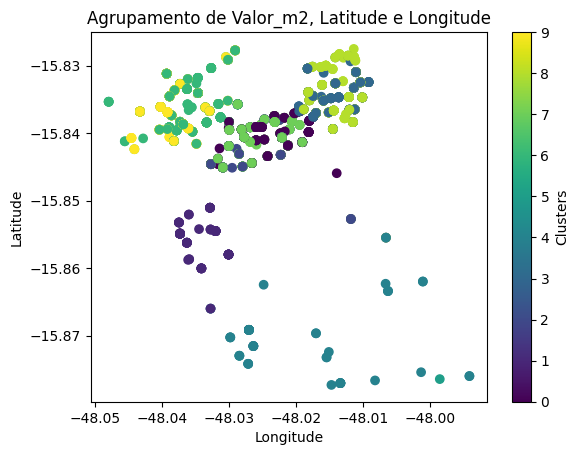

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Carregar os dados
# df = pd.read_csv('seu_arquivo.csv')  # Substitua 'seu_arquivo.csv' pelo nome do seu arquivo de dados

# Selecionar as variáveis relevantes
variables = df[['valor_m2', 'latitude', 'longitude']]

# Normalizar as variáveis
normalized_df = (variables - variables.mean()) / variables.std()

# Definir o número de clusters
num_clusters = 10

# Executar o algoritmo de agrupamento (K-means)
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(normalized_df)

# Obter os rótulos de cluster para cada amostra
cluster_labels = kmeans.labels_

# Adicionar os rótulos de cluster ao DataFrame original
df['cluster'] = cluster_labels

# Visualizar os resultados
plt.scatter(df['longitude'], df['latitude'], c=df['cluster'], cmap='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Agrupamento de Valor_m2, Latitude e Longitude')

# Adicionar legenda para as cores dos clusters
cbar = plt.colorbar()
cbar.set_label('Clusters')

plt.show();